#### Problem Statement

This notebook solves a **production planning optimization problem** for a single facility over 5 months. The goal is to determine the number of units to produce in each month to meet future demands at the **minimum total cost**, while respecting production **capacity constraints**.


#### Mathematical Formulation

**Sets:**

* $i, j \in \{1, \dots, 5\}$: months (Jan–May)

**Parameters:**

* $D_j$: Demand in month $j$
* $P_i$: Production capacity in month $i$
* $C_{ij}$: Cost to produce in month $i$ for demand in month $j$

**Decision Variables:**

* $x_{ij} \geq 0$: Units produced in month $i$ for month $j$

**Objective Function:**

$$
\min \sum_{i=1}^{5} \sum_{j=i}^{5} C_{ij} \cdot x_{ij}
$$

**Constraints:**

1. Demand fulfillment:

$$
\sum_{i=1}^{j} x_{ij} = D_j \quad \forall j
$$

2. Capacity limits:

$$
\sum_{j=i}^{5} x_{ij} \leq P_i \quad \forall i
$$

3. Non-negativity:

$$
x_{ij} \geq 0
$$



In [25]:
import gurobipy as gp
from gurobipy import GRB

# Define months
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May']
n = len(months)

# Parameters
demand = [200, 250, 150, 80, 120]
capacity = [250, 225, 250, 200, 225]

# Cost matrix
INF = 1e4
cost = [
    [24, 29, 34, 39, 44],       # Jan
    [INF, 27, 32, 37, 42],      # Feb
    [INF, INF, 32, 37, 42],     # Mar
    [INF, INF, INF, 50, 55],    # Apr
    [INF, INF, INF, INF, 34],   # May
]

# Create optimization model
model = gp.Model("Production_Planning")

# Decision variables
x = {}
for i in range(n):
    for j in range(i, n):
        x[i, j] = model.addVar(lb=0, vtype=GRB.CONTINUOUS, name=f"x_{i}_{j}")


# Constraints

# 1. Demand satisfaction
for j in range(n):
    model.addConstr(
        gp.quicksum(x[i, j] for i in range(j + 1)) == demand[j],
        name=f"demand_{j}"
    )

# 2. Production capacity
for i in range(n):
    model.addConstr(
        gp.quicksum(x[i, j] for j in range(i, n)) <= capacity[i],
        name=f"capacity_{i}"
    )

# Objective: minimize total production cost
model.setObjective(
    gp.quicksum(cost[i][j] * x[i, j] for i in range(n) for j in range(i, n)),
    GRB.MINIMIZE
)

# Optimize
model.optimize()

# Output results
if model.status == GRB.OPTIMAL:
    print(f"\n Optimal Total Cost: {model.objVal}\n")
    print("Production Plan:")
    for i in range(n):
        for j in range(i, n):
            qty = x[i, j].x
            if qty > 0:
                print(f"  - Produce {qty:.0f} units in {months[i]} for {months[j]}")
else:
    print(" No optimal solution found.")


Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 10 rows, 15 columns and 30 nonzeros
Model fingerprint: 0xcec1f001
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+01, 6e+01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [8e+01, 2e+02]
Presolve removed 10 rows and 15 columns
Presolve time: 0.03s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.3440000e+04   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.03 seconds (0.00 work units)
Optimal objective  2.344000000e+04

 Optimal Total Cost: 23440.0

Production Plan:
  - Produce 200 units in Jan for Jan
  - Produce 25 units in Jan for Feb
  - Produce 225 units in Feb for Feb
  - Produce 150 units in Mar for Mar


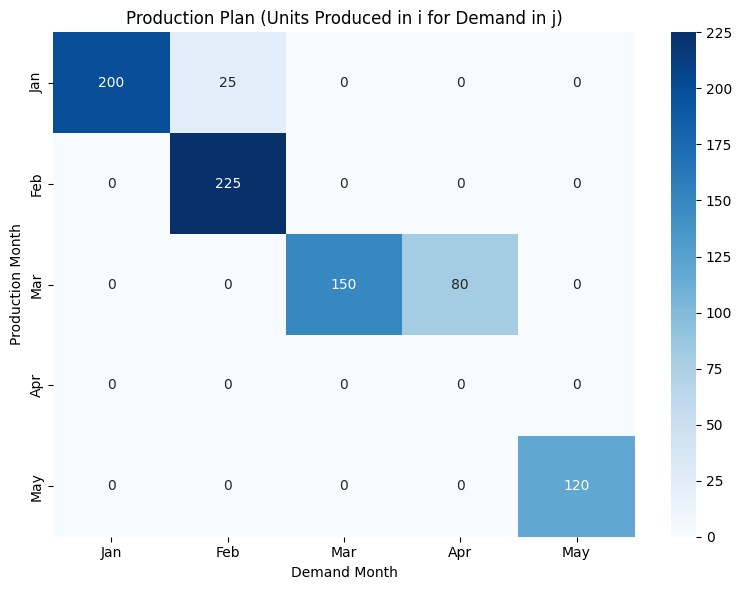

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Prepare the solution matrix
solution_matrix = np.zeros((n, n))
capacity_used = np.zeros(n)

for i in range(n):
    for j in range(i, n):
        qty = x[i, j].x
        solution_matrix[i, j] = qty
        capacity_used[i] += qty

# Heatmap of Production Plan ---
plt.figure(figsize=(8, 6))
sns.heatmap(solution_matrix, annot=True, fmt=".0f", cmap="Blues",
            xticklabels=months, yticklabels=months)
plt.title("Production Plan (Units Produced in i for Demand in j)")
plt.xlabel("Demand Month")
plt.ylabel("Production Month")
plt.tight_layout()
plt.show()



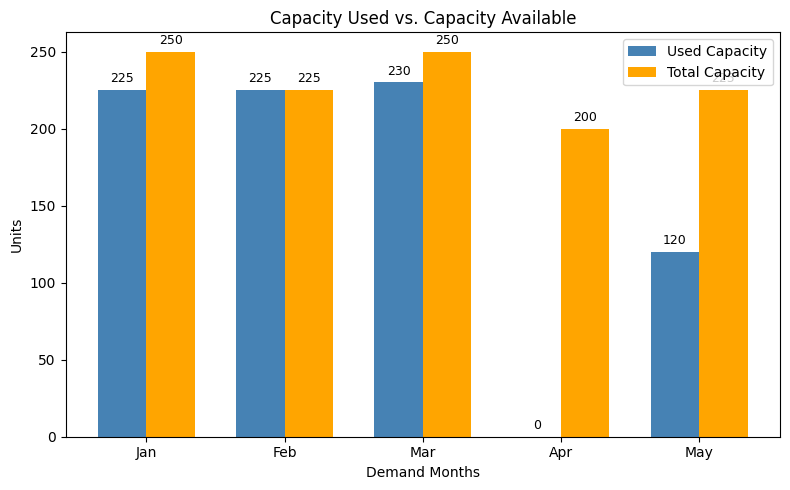

In [27]:
# Capacity Usage vs Capacity Limit (with value labels) ---
plt.figure(figsize=(8, 5))
bar_width = 0.35
index = np.arange(n)
bars1 = plt.bar(index, capacity_used, bar_width, label='Used Capacity', color='steelblue')
bars2 = plt.bar(index + bar_width, capacity, bar_width, label='Total Capacity', color='orange')

# Axis setup
plt.xticks(index + bar_width / 2, months)
plt.ylabel("Units")
plt.xlabel("Demand Months")
plt.title("Capacity Used vs. Capacity Available")
plt.legend()
plt.tight_layout()

# Add value labels
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 3, f'{int(height)}', ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 3, f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.show()




### Solution Interpretation

The Gurobi Optimizer successfully solved the production planning model in **0.01 seconds**, identifying an **optimal production plan** with a **total cost of \$23,440**.

* **All monthly demands are met** exactly as required.
* **No production capacity is exceeded** in any month.
* The solver used **presolve optimizations** to reduce the problem to a trivial form (all constraints and variables were satisfied during presolve), indicating a well-structured, deterministic model.

#### Optimal Production Plan:

| Production Month | For Demand Month | Units |
| ---------------- | ---------------- | ----- |
| January          | January          | 200   |
| January          | February         | 25    |
| February         | February         | 225   |
| March            | March            | 150   |
| March            | April            | 80    |
| May              | May              | 120   |


* The model chooses to **start February's production early**, allocating 25 units in January and the remaining 225 in February, likely due to **lower cost in January** (\$29 vs. \$27).
* **All other months' demands are met in their respective or earliest feasible production months**, minimizing costs while respecting capacity.
* **April's demand is fulfilled entirely by March's production**, avoiding the higher cost of producing in April (\$50 vs. \$37).
* No production is scheduled in April (despite available capacity), showing that it's **not cost-effective** compared to adjacent months.
